In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

# Homework week1_2 — Xác suất thống kê cho AI

Bài làm sử dụng dataset Iris. Dataset gồm 4 biến số: sepal length, sepal width, petal length, petal width và một biến phân loại là species.

In [3]:
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=["sepal_length", "sepal_width", "petal_length", "petal_width"]
)

df["species"] = [iris.target_names[i] for i in iris.target]

print("5 dong dau")
display(df.head())

print("Shape:", df.shape)

print("Kieu du lieu")
print(df.dtypes)

5 dong dau


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Shape: (150, 5)
Kieu du lieu
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


Nhận xét:
- Dataset Iris có 150 dòng và 5 cột. Trong đó có "species" là biến phân loại và 4 biến số là "sepal_length","sepal_width", "petal_length", petal_width"
- 4 cột đầu thì có kiểu dữ liệu "float64" nghĩa là dữ liệu số thực. Còn cột species có dữ liệu dạng "object" nghĩa là dữ liệu dạng chữ

In [4]:
numeric_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

stats = pd.DataFrame(index = numeric_cols)

stats["mean"] = df[numeric_cols].mean()
stats["median"] = df[numeric_cols].median()
stats["mode"] = df[numeric_cols].mode().iloc[00]
stats["var"] = df[numeric_cols].var()
stats["std"] = df[numeric_cols].std()
stats["min"] = df[numeric_cols].min()
stats["max"] = df[numeric_cols].max()
stats["Q1"] = df[numeric_cols].quantile(0.25)
stats["Q3"] = df[numeric_cols].quantile(0.75)
stats["IQR"] = stats["Q3"] - stats["Q1"]

display(stats)


,mean,median,mode,var,std,min,max,Q1,Q3,IQR
sepal_length,5.843333,5.80,5.0,0.685694,0.828066,4.3,7.9,5.1,6.4,1.3
sepal_width,3.057333,3.00,3.0,0.189979,0.435866,2.0,4.4,2.8,3.3,0.5
petal_length,3.758000,4.35,1.4,3.116278,1.765298,1.0,6.9,1.6,5.1,3.5
petal_width,1.199333,1.30,0.2,0.581006,0.762238,0.1,2.5,0.3,1.8,1.5


In [5]:
group_stats = df.groupby("species")[numeric_cols].agg(["mean", "std"])
display(group_stats)

sepal_length           sepal_width           petal_length  \
                   mean       std        mean       std         mean   
species                                                                
setosa            5.006  0.352490       3.428  0.379064        1.462   
versicolor        5.936  0.516171       2.770  0.313798        4.260   
virginica         6.588  0.635880       2.974  0.322497        5.552   

                     petal_width            
                 std        mean       std  
species                                     
setosa      0.173664       0.246  0.105386  
versicolor  0.469911       1.326  0.197753  
virginica   0.551895       2.026  0.274650

Nhận xét Phần 1

-Bảng thống kê cho thấy "petal_length" và "petal_width" có độ biến thiên lớn hơn các biến còn lại, đặc biệt "petal_length" có IQR cao nhất

- Khi xét theo từng loài, setosa có "petal_length" và "petal_width" nhỏ nhất, còn virginica có giá trị lớn nhất. Vì vậy, hai biến cánh hoa này giúp phân biệt các loài rõ hơn so với "sepal_length" và "sepal_width"

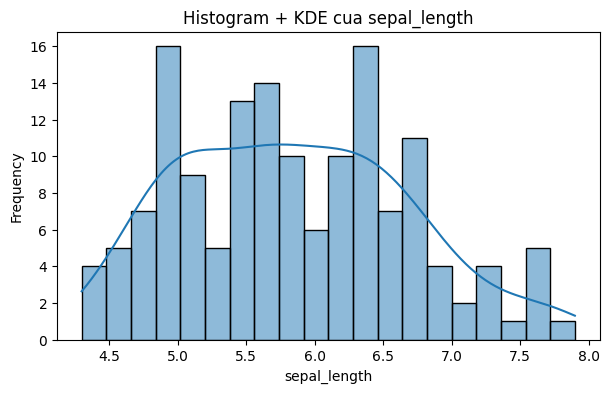

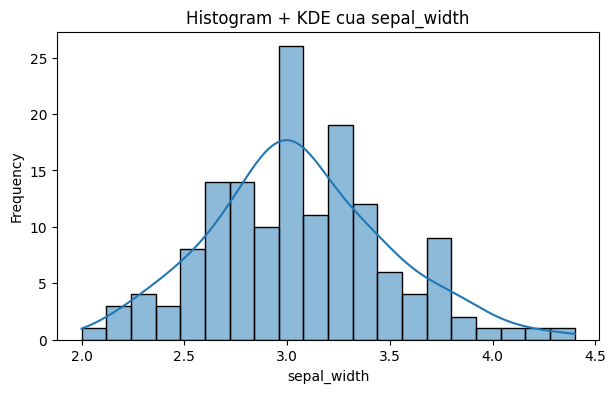

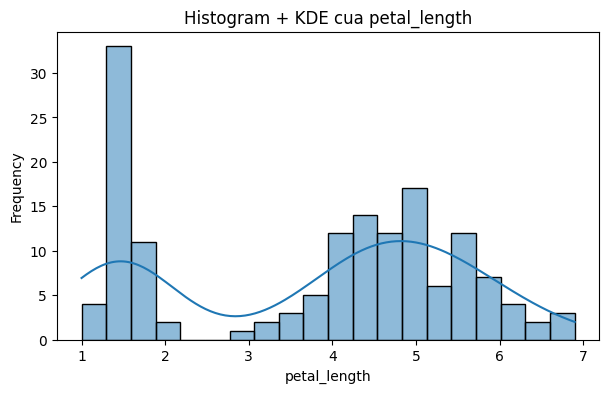

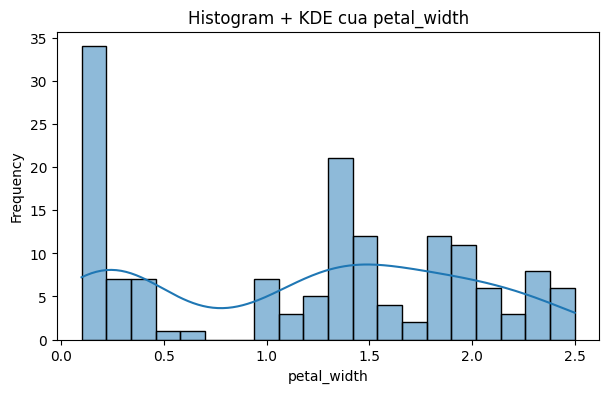

In [6]:
for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f"Histogram + KDE cua {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

Nhận xét histogram và KDE
- Biến "sepal_length" có phân phối tương đối gần dạng chuông nhưng vẫn hơi lệch. Biến "sepal_width" tập trung nhiều quanh khoảng 3.0 và có dạng gần phân phối chuẩn.
- Hai biến "petal_length" và "petal_width" có phân phối nhiều đỉnh rõ hơn. Nguyên nhân là dữ liệu Iris gồm nhiều loài hoa khác nhau, mỗi loài có kích thước cánh hoa khác nhau.

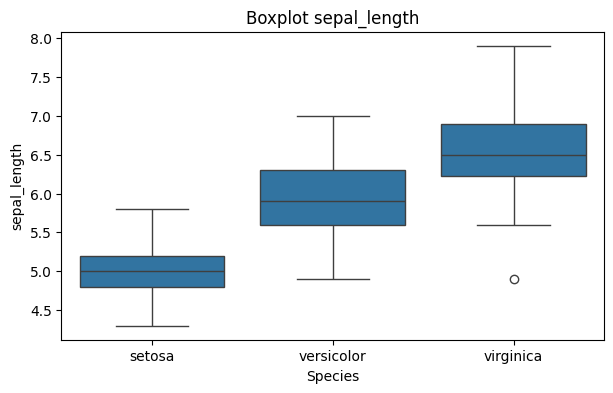

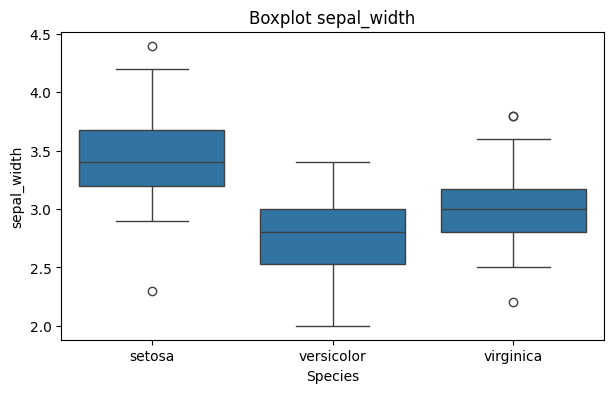

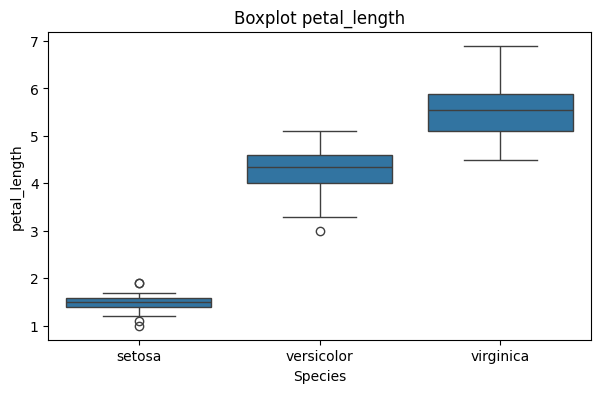

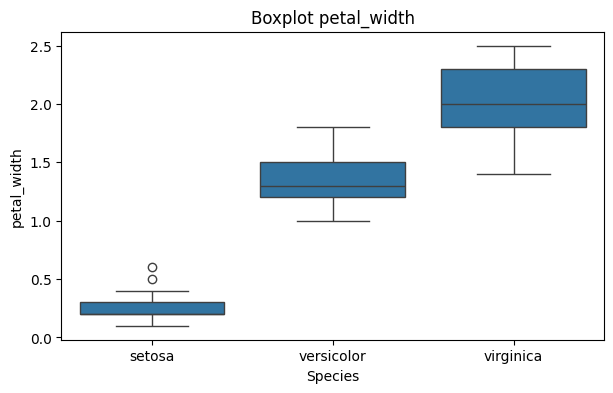

In [11]:
for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x="species", y=col)
    plt.title(f"Boxplot {col}")
    plt.xlabel("Species")
    plt.ylabel(col)
    plt.show()

Nhận xét boxplot

- Boxplot cho thấy "petal_length" và "petal_width" phân biệt các loài rõ nhất. Loài setosa có giá trị nhỏ hơn hẳn so với versicolor và virginica.
- Ở "sepal_length", virginica lớn nhất, setosa nhỏ nhất. Ở "sepal_width có sự chồng lấp giữa các loài nhiều hơn nên khả năng phân biệt kém hơn.

Mean: 5.843333333333334
Std: 0.828066127977863


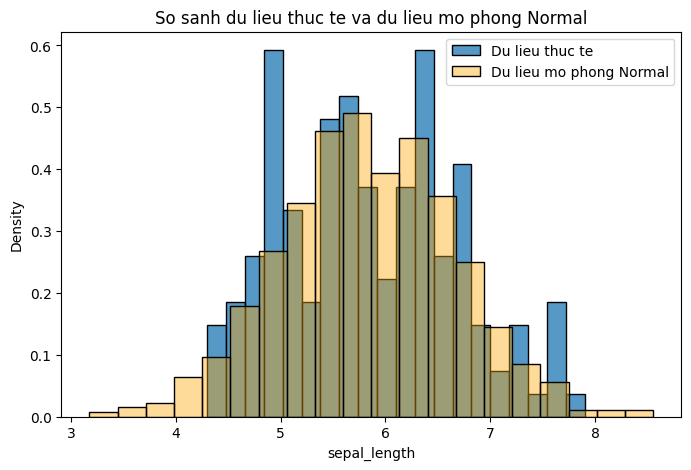

In [12]:
col = "sepal_length"

data = df[col]

mean_value = data.mean()
std_value = data.std()

print("Mean:", mean_value)
print("Std:", std_value)

sim_data = np.random.normal(
    loc=mean_value,
    scale=std_value,
    size=1000
)

plt.figure(figsize=(8, 5))

sns.histplot(
    data,
    bins=20,
    stat="density",
    label="Du lieu thuc te"
)

sns.histplot(
    sim_data,
    bins=20,
    stat="density",
    color="orange",
    alpha=0.4,
    label="Du lieu mo phong Normal"
)

plt.title("So sanh du lieu thuc te va du lieu mo phong Normal")
plt.xlabel(col)
plt.ylabel("Density")
plt.legend()
plt.show()

Nhận xét mô phỏng Normal
- Biến "sepal_length" có phân phối khá gần với dữ liệu mô phỏng Normal vì hai histogram chồng lên nhau khá là nhiều
- Tuy nhiên, dữ liệu thực tế không khớp hoàn toàn với phân phối Normal do dataset Iris gồm nhiều loài hoa khác nhau, làm phân phối có thể bị lệch hoặc có nhiều cụm nhỏ

In [13]:
data_num = df[numeric_cols]

cov_matrix = data_num.cov()

corr_matrix = data_num.corr()

print("Ma tran hiep phuong sai:")
display(cov_matrix)

print("Ma tran tuong quan:")
display(corr_matrix)

Ma tran hiep phuong sai:


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,0.685694,-0.042434,1.274315,0.516271
sepal_width,-0.042434,0.189979,-0.329656,-0.121639
petal_length,1.274315,-0.329656,3.116278,1.295609
petal_width,0.516271,-0.121639,1.295609,0.581006


Ma tran tuong quan:


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


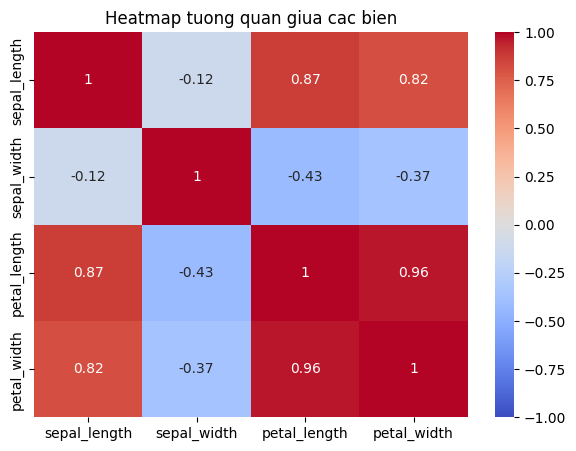

In [14]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Heatmap tuong quan giua cac bien")
plt.show()

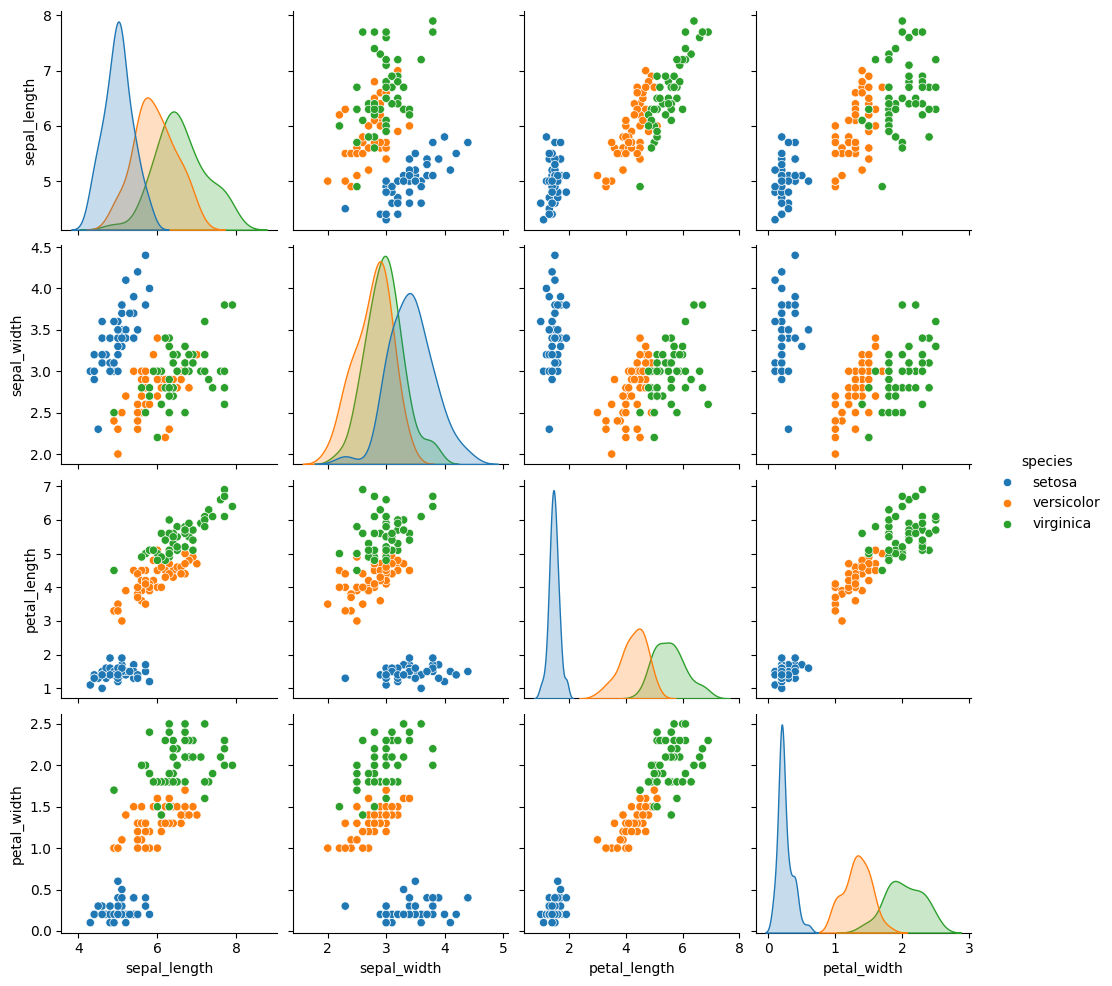

In [15]:
sns.pairplot(df, hue="species")
plt.show()

Nhận xét Phần 3
- Ma trận tương quan cho thấy "petal_length" và "petal_width" có tương quan dương rất mạnh, khoảng 0.96. Điều này nghĩa là khi chiều dài cánh hoa tăng thì chiều rộng cánh hoa cũng thường tăng.
- "sepal_width" có tương quan âm với các biến còn lại, nên mối liên hệ không mạnh bằng nhóm petal.
- Heatmap và pairplot cho thấy loài setosa tách biệt rõ nhất, đặc biệt theo "petal_length" và "petal_width". Hai loài versicolor và virginica gần nhau hơn nhưng vẫn có thể phân biệt tương đối dựa trên các biến cánh hoa.
--> "petal_length" và "petal_width" là hai đặc trưng quan trọng nhất để phân biệt các loài Iris.

## Phần 4
- Bài toán xét nghiệm bệnh. Gọi:
+ "B": người đó thật sự mắc bệnh
+ "+": kqua xét nghiệm dương tính
Tính "P(B|+)" tức là xác suất người đó thực sự mắc bệnh khi đã biết kết quả là dương tính.

In [17]:
P_B = 0.01

P_not_B = 1 - P_B

P_pos_given_B = 0.99

P_pos_given_not_B = 0.05

P_pos = P_pos_given_B * P_B + P_pos_given_not_B * P_not_B

P_B_given_pos = (P_pos_given_B * P_B) / P_pos

print("P(+):", P_pos)
print("P(B|+):", P_B_given_pos)
print("P(B|+) theo phan tram:", P_B_given_pos * 100, "%")

P(+): 0.0594
P(B|+): 0.16666666666666669
P(B|+) theo phan tram: 16.666666666666668 %


Nhận xét Bayes
- Kết quả cho thấy xác suất có kết quả dương tính là "P(+) = 0.0594"
- Sau khi áp dụng định lý Bayes, xác suất thật sự mắc bệnh khi test dương tính là "P(B|+) ≈ 0.1667", tức khoảng "16.67%".
- Mặc dù xét nghiệm có độ nhạy cao "99%", xác suất mắc bệnh sau khi dương tính vẫn không quá cao vì tỉ lệ mắc bệnh ban đầu chỉ là "1%". Điều này cho thấy xác suất ban đầu ảnh hưởng rất mạnh đến kết quả cuối cùng.

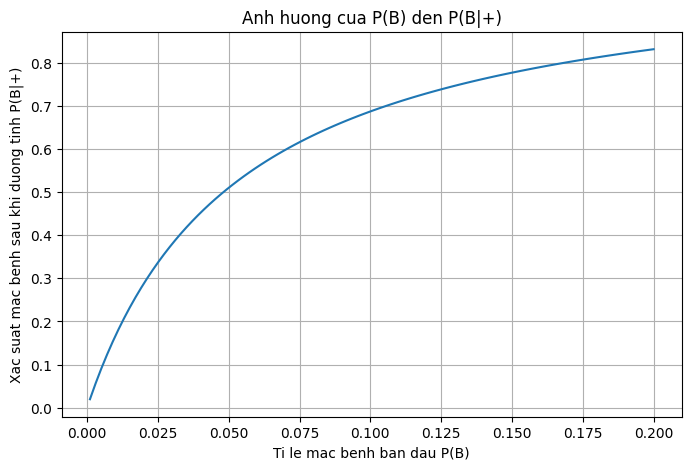

In [18]:
P_B_list = np.linspace(0.001, 0.2, 100)

ket_qua = []

for P_B in P_B_list:
    P_not_B = 1 - P_B
    
    P_pos = P_pos_given_B * P_B + P_pos_given_not_B * P_not_B
    
    P_B_given_pos = (P_pos_given_B * P_B) / P_pos
    
    ket_qua.append(P_B_given_pos)

plt.figure(figsize=(8, 5))
plt.plot(P_B_list, ket_qua)

plt.xlabel("Ti le mac benh ban dau P(B)")
plt.ylabel("Xac suat mac benh sau khi duong tinh P(B|+)")
plt.title("Anh huong cua P(B) den P(B|+)")
plt.grid(True)
plt.show()

Nhận xét biểu đồ Bayes
- Biểu đồ cho thấy khi tỉ lệ mắc bệnh ban đầu "P(B)" tăng thì xác suất mắc bệnh sau khi test dương tính "P(B|+)" cũng tăng
- Ở vùng "P(B)" nhỏ, "P(B|+)" tăng rất nhanh. Điều này cho thấy xác suất ban đầu có ảnh hưởng mạnh đến kết quả Bayes.

-->Vì vậy, khi đánh giá một kết quả dương tính, không chỉ xét độ chính xác của xét nghiệm mà còn phải xét tỉ lệ mắc bệnh ban đầu